<a href="https://colab.research.google.com/github/pedrotamani/online-purchase-analysis/blob/main/Analisis_Exploratorio_de_Compras_Online.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importar los datasets




In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

In [18]:
tienda1["tienda"] = "Tienda 1"
tienda2["tienda"] = "Tienda 2"
tienda3["tienda"] = "Tienda 3"
tienda4["tienda"] = "Tienda 4"

##Uniendo los datasets en uno sólo

In [19]:
sales = pd.concat([tienda1, tienda2, tienda3, tienda4])

#2. Exploratory Data Analysis (EDA)


##Revisar estructura del dataset

In [20]:
sales.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


In [21]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9435 entries, 0 to 2357
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 1.3+ MB


In [22]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,9435.0,466732.294648,590320.675315,7600.00000,55200.00000,221500.00000,663300.00000,2.977000e+06
Costo de envío,9435.0,24875.145734,31480.036346,0.00000,3000.00000,11700.00000,34900.00000,1.625000e+05
Calificación,9435.0,4.014520,1.390518,1.00000,3.00000,5.00000,5.00000,5.000000e+00
Cantidad de cuotas,9435.0,2.927398,2.802776,1.00000,1.00000,1.00000,4.00000,2.400000e+01
lat,9435.0,5.428909,2.355663,-4.21528,4.60971,4.60971,6.25184,1.154444e+01
lon,9435.0,-74.760108,1.207155,-77.28111,-75.56359,-74.19904,-74.08175,-6.792390e+01


##Limpieza de datos

In [23]:
sales = sales.drop_duplicates()

In [24]:
sales.isnull().sum()

,0
Producto,0
Categoría del Producto,0
Precio,0
Costo de envío,0
Fecha de Compra,0
Vendedor,0
Lugar de Compra,0
Calificación,0
Método de pago,0
Cantidad de cuotas,0


##Convertir fechas

In [25]:
sales['Fecha de Compra'] = pd.to_datetime(sales['Fecha de Compra'])

/tmp/ipykernel_299/2507745639.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sales['Fecha de Compra'] = pd.to_datetime(sales['Fecha de Compra'])


In [26]:
sales.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


In [27]:
sales['month'] = sales['Fecha de Compra'].dt.month
sales['year'] = sales['Fecha de Compra'].dt.year
sales['day'] = sales['Fecha de Compra'].dt.day

In [28]:
sales.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tienda,month,year,day
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1,1,2021,16
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1,5,2022,18
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1,3,2021,15
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1,5,2022,3
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1,11,2020,7


##Crear una variable de valor de venta
Como no existe cantidad, asumimos que cada fila es una venta. Entonces el valor de la venta sería:

                      precio + costo de envío

In [29]:
sales['Valor_Venta'] = sales['Precio'] + sales['Costo de envío']

##Ventas por tienda

###Ventas totales por tienda:

In [51]:
sales.groupby('tienda')['Valor_Venta'].sum().sort_values(ascending=False)

,Valor_Venta
tienda,
Tienda 1,1.212258e+09
Tienda 2,1.175829e+09
Tienda 3,1.156536e+09
Tienda 4,1.093693e+09


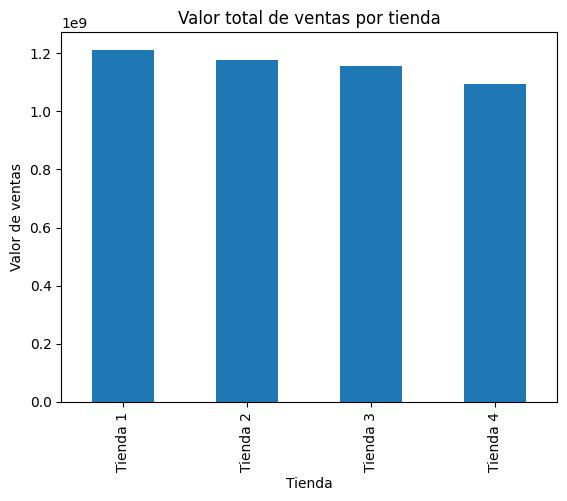

In [52]:
import matplotlib.pyplot as plt

store_sales = sales.groupby('tienda')['Valor_Venta'].sum()

store_sales.plot(kind='bar')

plt.title("Valor total de ventas por tienda")
plt.ylabel("Valor de ventas")
plt.xlabel("Tienda")

plt.show()

##Productos más vendidos

In [53]:
sales['Producto'].value_counts().head(10)

,count
Producto,
Mesa de noche,210
Carrito de control remoto,206
Microondas,206
Batería,203
Cama king,201
Secadora de ropa,200
Modelado predictivo,200
Set de ollas,200
Cama box,199


In [54]:
sales.groupby('Producto')['Valor_Venta'].sum().sort_values(ascending=False).head(10)

,Valor_Venta
Producto,
TV LED UHD 4K,455524500.0
Iphone 15,422445600.0
Refrigerador,405393000.0
Smart TV,305662600.0
Lavadora de ropa,255357300.0
Lavavajillas,253345200.0
Tablet ABXY,230721200.0
Secadora de ropa,221432200.0
Celular ABXY,166322800.0


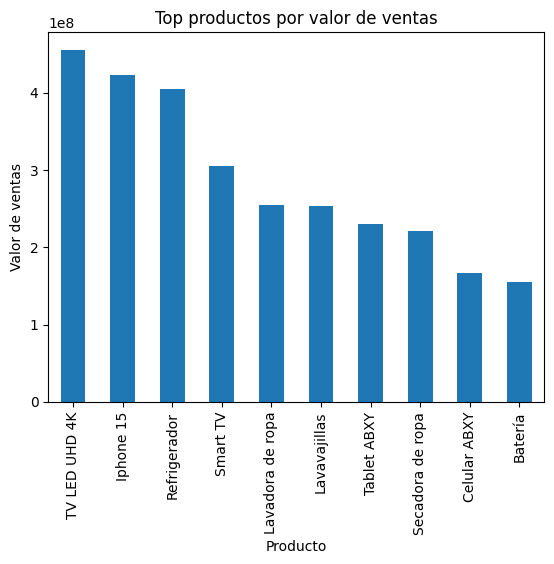

In [55]:
top_products = sales.groupby('Producto')['Valor_Venta'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title("Top productos por valor de ventas")
plt.ylabel("Valor de ventas")

plt.show()

##Categorías con más ventas

In [56]:
sales.groupby('Categoría del Producto')['Valor_Venta'].sum().sort_values(ascending=False)

,Valor_Venta
Categoría del Producto,
Electrónicos,1.749039e+09
Electrodomésticos,1.395147e+09
Muebles,7.981114e+08
Instrumentos musicales,3.672769e+08
Deportes y diversión,1.506693e+08
Juguetes,7.762570e+07
Artículos para el hogar,6.069090e+07
Libros,3.975600e+07


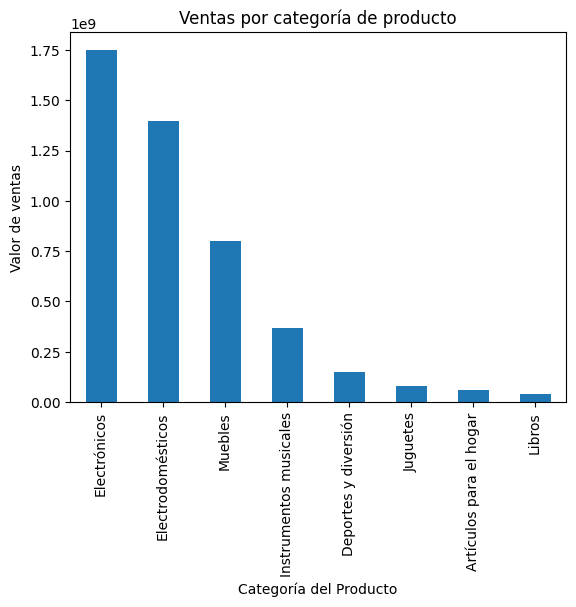

In [57]:
category_sales = sales.groupby('Categoría del Producto')['Valor_Venta'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')

plt.title("Ventas por categoría de producto")
plt.ylabel("Valor de ventas")

plt.show()

##Métodos de pago más usados

In [58]:
sales['Método de pago'].value_counts()

,count
Método de pago,
Tarjeta de crédito,6898
Nequi,1900
Cupón,504
Tarjeta de débito,133


In [59]:
sales.groupby('Método de pago')['Valor_Venta'].sum().sort_values(ascending=False)

,Valor_Venta
Método de pago,
Tarjeta de crédito,3.402935e+09
Nequi,9.274227e+08
Cupón,2.484758e+08
Tarjeta de débito,5.948250e+07


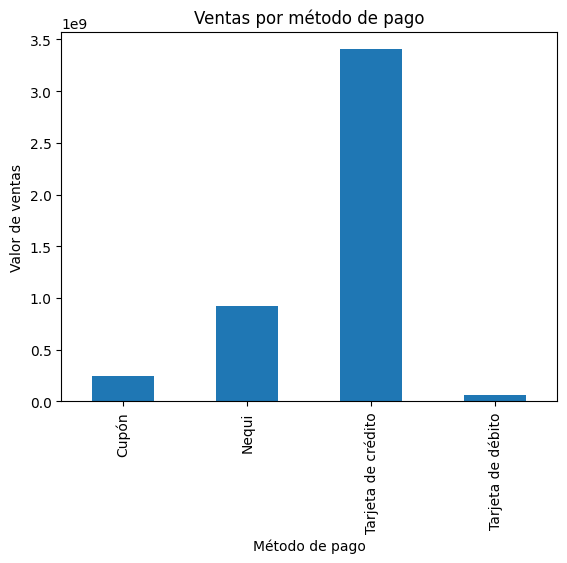

In [60]:
payment_sales = sales.groupby('Método de pago')['Valor_Venta'].sum()

payment_sales.plot(kind='bar')

plt.title("Ventas por método de pago")
plt.ylabel("Valor de ventas")

plt.show()

##Análisis de cuotas

In [61]:
sales.groupby('Cantidad de cuotas')['Valor_Venta'].sum().sort_values(ascending=False)

,Valor_Venta
Cantidad de cuotas,
1,2.305229e+09
2,5.422838e+08
3,4.717269e+08
10,3.074114e+08
4,3.038699e+08
5,2.426325e+08
6,1.782615e+08
8,1.767799e+08
7,6.361720e+07


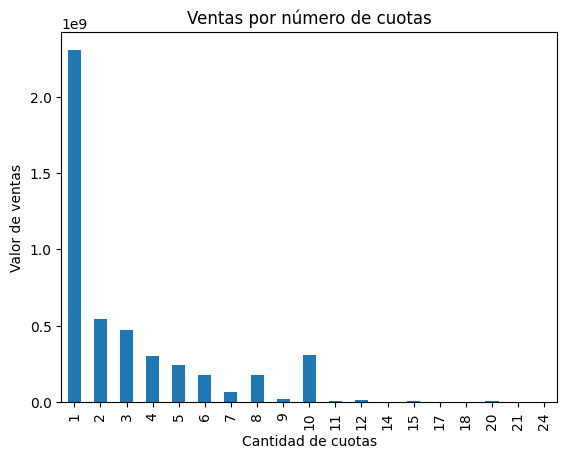

In [62]:
installments = sales.groupby('Cantidad de cuotas')['Valor_Venta'].sum()

installments.plot(kind='bar')

plt.title("Ventas por número de cuotas")
plt.ylabel("Valor de ventas")

plt.show()

##Tendencia de ventas en el tiempo

In [63]:
sales['Fecha de Compra'] = pd.to_datetime(sales['Fecha de Compra'])

In [64]:
sales['mes'] = sales['Fecha de Compra'].dt.month

In [65]:
monthly_sales = sales.groupby('mes')['Valor_Venta'].sum()

monthly_sales

,Valor_Venta
mes,
1,470479200.0
2,459320700.0
3,473388200.0
4,382167900.0
5,355448600.0
6,311808500.0
7,367221800.0
8,369240200.0
9,386420600.0


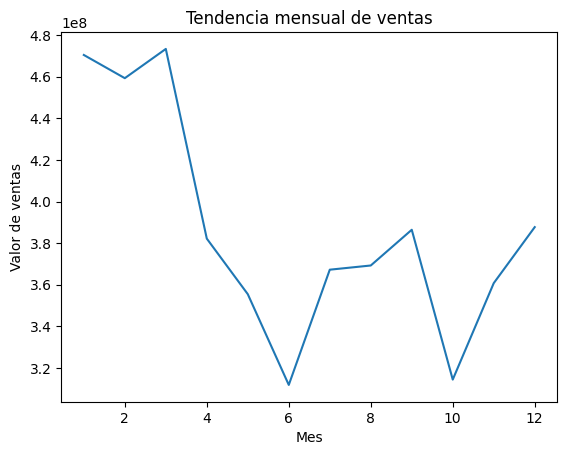

In [66]:
monthly_sales.plot(kind='line')

plt.title("Tendencia mensual de ventas")
plt.ylabel("Valor de ventas")
plt.xlabel("Mes")

plt.show()

##Relación precio – calificación

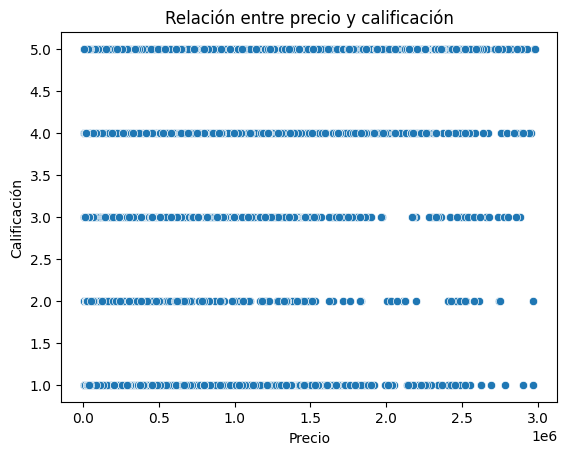

In [67]:
import seaborn as sns

sns.scatterplot(data=sales, x="Precio", y="Calificación")

plt.title("Relación entre precio y calificación")

plt.show()

In [68]:
sales.to_csv("retail_sales_clean.csv", index=False)